In [90]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler


df = pd.read_parquet("../data/per_state.parquet")

first, we will see how "safe" our states are, we will use k-means to make a clusters of how many incidents, injuries and deaths per capita in states.

In [91]:
df_norm = df.copy()
df_norm

,population,incidents,killed,injured,incidents_per_thousand,killed_per_thousand,injured_per_thousand
state,,,,,,,
District of Columbia,675400,3195,459,1415,4.730530,0.679597,2.095055
Alaska,737498,1349,267,325,1.829158,0.362035,0.440679
Delaware,941252,1685,217,853,1.790169,0.230544,0.906240
Louisiana,4664628,8103,2179,4398,1.737116,0.467133,0.942840
South Carolina,4891938,6939,1610,3084,1.418456,0.329113,0.630425
Illinois,12858913,17556,3409,13514,1.365279,0.265108,1.050944
Mississippi,2988471,3599,1176,1883,1.204295,0.393512,0.630088
Tennessee,6591170,7626,1824,4478,1.157002,0.276734,0.679394
Alabama,4852347,5471,1880,2998,1.127496,0.387441,0.617845


In [92]:
#cols = ["incidents_per_thousand", "killed_per_thousand", "injured_per_thousand"]
#for c in cols:
   # df_norm[f"{c}_norm"] = (df_norm[c] - df_norm[c].min()) / (df_norm[c].max() - df_norm[c].min())

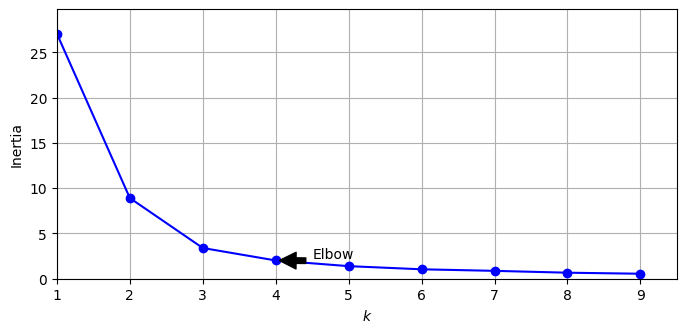

In [93]:
cols = ["incidents_per_thousand", "killed_per_thousand", "injured_per_thousand"]
X = df_norm[cols].values

kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
                for k in range(1, 10)]
inertias = [m.inertia_ for m in kmeans_per_k]

elbow_k = 4

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate("Elbow",
             xy=(elbow_k, inertias[elbow_k - 1]),
             xytext=(elbow_k + 0.5, inertias[elbow_k - 1] + 0.3),
             arrowprops=dict(facecolor="black", shrink=0.1))
plt.axis([1, 9.5, 0, max(inertias) * 1.1])
plt.grid()
plt.show()

In [94]:
X = MinMaxScaler().fit_transform(df[["incidents_per_thousand", "killed_per_thousand", "injured_per_thousand"]])
df_norm["cluster"] = KMeans(n_clusters=7, random_state=42, n_init=10).fit_predict(X)

In [95]:
import plotly.express as px
fig = px.scatter_3d(df_norm, x="incidents_per_thousand",
                    y="killed_per_thousand", z="injured_per_thousand",
                    color="cluster", hover_name=df_norm.index)
fig.show()

We will make some regressions and analysis to see how much particular attributes corelate to the statistics about killings, injuries and incidents per 100k people in states,


We will use external datasets.
The first one will be the income of particular states (data from https://nces.ed.gov/programs/digest/d16/tables/dt16_102.30.asp , this is a government site)

In [96]:
df_money = pd.read_csv("../data/state_income_2015.csv")

In [97]:
Median_Income_USA = df_money.loc[df_money['state'] == "United States"]['median_household_income_2015'].values[0]
Median_Income_USA

np.int64(55800)

In [98]:
df = df.merge(df_money[['state', 'median_household_income_2015']], on='state', how='left')


next, the temperature from each state (data from https://www.currentresults.com/Weather/US/average-annual-state-temperatures.php )

In [99]:
df_temperature = pd.read_csv("../data/state_temperature.csv")
df = df.merge(df_temperature[['state', 'avg_temp_c']], on='state', how='left')
#there is no info about DC, so I just searched it, it is 15 C
df.loc[df['state'] == "District of Columbia", 'avg_temp_c'] = 15

next, urbanization data per state. There was no data for 2015, this data is to be found only every 10 years. We have data from 2010 from Iowa University. https://www.icip.iastate.edu/tables/population/urban-pct-states

In [100]:
df_urbanization = pd.read_csv("../data/state_urbanization.csv")
df = df.merge(df_urbanization[['state', 'urbanization_2010']], on='state', how='left')

In 2016 there was an election in the USA. Our data is from that period. We added % of people who voted for Trump and Clinton in that year per state. Data is from wikipedia

In [101]:
df_votes = pd.read_csv("../data/state_election_2016.csv")
df = df.merge(df_votes[['state', 'Clinton_votes']], on='state', how='left')
df = df.merge(df_votes[['state', 'Trump_votes']], on='state', how='left')

now, the median state age. We have already done some plots when it came for particular people. Data is from 2020 from wikipedia

In [102]:
df_age = pd.read_csv("../data/state_median_age.csv")
df = df.merge(df_age[['state', 'median_age']], on='state', how='left')

let's now look at ethnicity https://pmc.ncbi.nlm.nih.gov/articles/PMC5848096/

In [103]:
df_race = pd.read_csv("../data/state_race_2015.csv")
df = df.merge(df_race[['state', 'pct_white']], on='state', how='left')
df = df.merge(df_race[['state', 'pct_black']], on='state', how='left')
df = df.merge(df_race[['state', 'pct_hispanic']], on='state', how='left')
df = df.merge(df_race[['state', 'pct_asian']], on='state', how='left')
df = df.merge(df_race[['state', 'pct_native']], on='state', how='left')
df = df.merge(df_race[['state', 'pct_mixed']], on='state', how='left')

now, unemployment https://www.bls.gov/opub/ted/2016/u-3-and-u-6-unemployment-by-state-2015.htm

In [104]:
df_unemployment = pd.read_csv("../data/state_unemployment_2015.csv")
df = df.merge(df_unemployment[['state', 'unemployment']], on='state', how='left')


now state education

In [105]:
df_education = pd.read_csv("../data/state_education.csv")
df = df.merge(df_education[['state', 'pct_bachelors']], on='state', how='left')

In [106]:
df

,state,population,incidents,killed,injured,incidents_per_thousand,killed_per_thousand,injured_per_thousand,median_household_income_2015,avg_temp_c,...,Trump_votes,median_age,pct_white,pct_black,pct_hispanic,pct_asian,pct_native,pct_mixed,unemployment,pct_bachelors
0,District of Columbia,675400,3195,459,1415,4.730530,0.679597,2.095055,75600,15.0,...,4.09,34.4,38.0,41.0,11.0,5.0,0.0,4.0,6.9,63.05
1,Alaska,737498,1349,267,325,1.829158,0.362035,0.440679,73400,-3.0,...,51.28,35.3,60.0,2.0,7.0,6.0,15.0,8.0,6.7,32.79
2,Delaware,941252,1685,217,853,1.790169,0.230544,0.906240,61300,12.9,...,41.71,41.4,61.0,22.0,10.0,4.0,0.0,3.0,5.0,35.62
3,Louisiana,4664628,8103,2179,4398,1.737116,0.467133,0.942840,45700,19.1,...,58.09,37.8,59.0,32.0,5.0,2.0,1.0,2.0,6.2,26.45
4,South Carolina,4891938,6939,1610,3084,1.418456,0.329113,0.630425,47200,16.9,...,54.94,40.1,64.0,26.0,6.0,2.0,0.0,2.0,5.9,31.53
5,Illinois,12858913,17556,3409,13514,1.365279,0.265108,1.050944,59600,11.0,...,38.76,38.8,61.0,14.0,18.0,6.0,0.0,2.0,5.9,37.14
6,Mississippi,2988471,3599,1176,1883,1.204295,0.393512,0.630088,40600,17.4,...,57.94,38.3,57.0,38.0,3.0,1.0,0.0,1.0,6.5,24.78
7,Tennessee,6591170,7626,1824,4478,1.157002,0.276734,0.679394,47300,14.2,...,60.72,39.1,74.0,16.0,6.0,2.0,0.0,2.0,5.7,30.48
8,Alabama,4852347,5471,1880,2998,1.127496,0.387441,0.617845,44800,17.1,...,62.08,39.5,65.0,27.0,4.0,1.0,0.0,2.0,6.1,27.43
9,Missouri,6071732,6631,2136,3585,1.092110,0.351794,0.590441,50200,12.5,...,56.77,39.1,79.0,11.0,4.0,2.0,0.0,3.0,NaN,31.72
